In [3]:
# Loan Approval Prediction using Machine Learning

## Problem Statement - Build a machine learning model to predict whether a loan will be approved based on applicant financial information.

## Import Librariesfrom google.colab import files
uploaded = files.upload()


NameError: name 'u' is not defined

In [4]:
# Loan Approval Prediction using Machine Learning

## Problem Statement - Build a machine learning model to predict whether a loan will be approved based on applicant financial information.

## Import Libraries
from google.colab import files
uploaded = files.upload()

Saving loan_data.csv to loan_data.csv


In [5]:
# --- STEP 2: Load and inspect data ---
import pandas as pd

# Load dataset from uploaded file
data = pd.read_csv('loan_data.csv')

# Explore data
print(data.head())
print(data.info())
print(data.isnull().sum())
print(data['loan_status'].value_counts())

   person_age person_gender person_education  person_income  person_emp_exp  \
0          22        female           Master          71948               0   
1          21        female      High School          12282               0   
2          25        female      High School          12438               3   
3          23        female         Bachelor          79753               0   
4          24          male           Master          66135               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT      35000    PERSONAL          16.02   
1                   OWN       1000   EDUCATION          11.14   
2              MORTGAGE       5500     MEDICAL          12.87   
3                  RENT      35000     MEDICAL          15.23   
4                  RENT      35000     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                           3           561  

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64


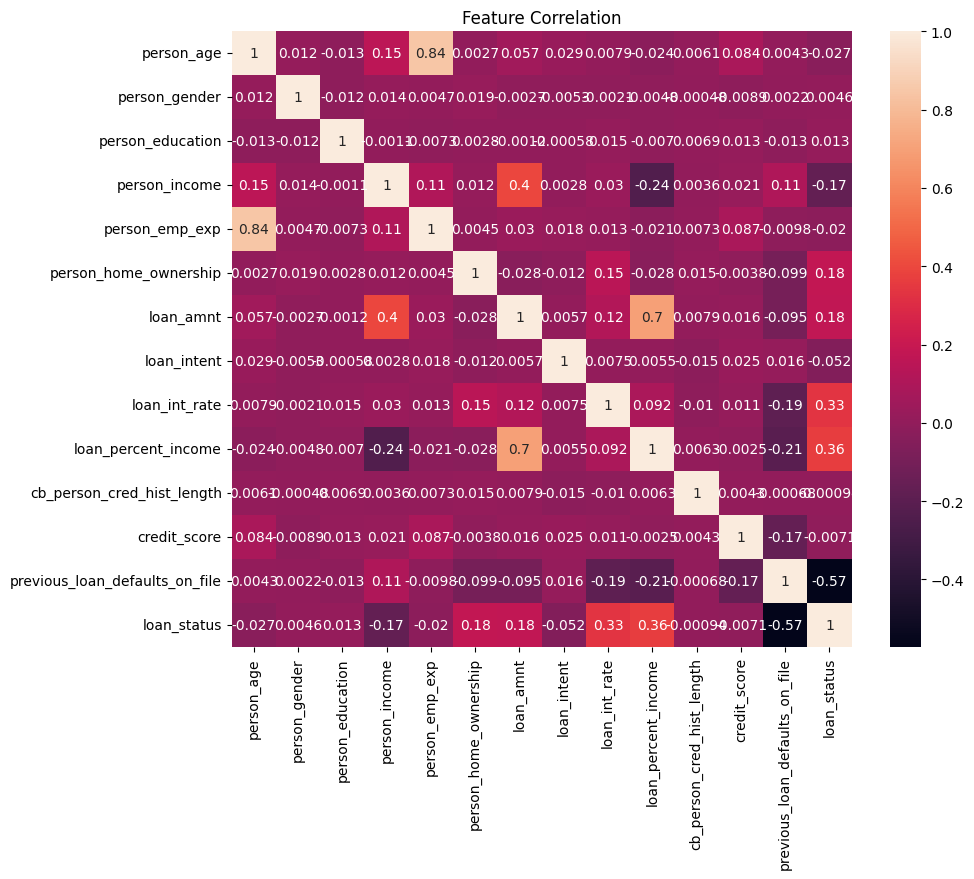

In [7]:
# --- STEP 3: Preprocessing ---
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Fill missing numerical values (if any)
data['loan_amnt'] = data['loan_amnt'].fillna(data['loan_amnt'].median())

# Fill missing categorical values (if any)
data['person_gender'] = data['person_gender'].fillna(data['person_gender'].mode()[0])

# Encode all categorical columns
categorical_cols = ['person_gender', 'person_education', 'person_home_ownership',
                    'loan_intent', 'previous_loan_defaults_on_file']
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

print(data.isnull().sum())    # Confirm no missing values

# Now that all relevant columns are numerical, plot the correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation")
plt.show()

In [9]:
# --- STEP 4: Train-test Split ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.drop('loan_status', axis=1)
y = data['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --- STEP 5: Train and Compare Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n{name} - Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

print("\n--- Model Comparison ---")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

# Choose best model (replace with your choice if needed)
best_model = models['Random Forest']


Logistic Regression - Test Accuracy: 0.8875
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      1523
           1       0.76      0.77      0.77       477

    accuracy                           0.89      2000
   macro avg       0.84      0.85      0.85      2000
weighted avg       0.89      0.89      0.89      2000


Random Forest - Test Accuracy: 0.9185
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      1523
           1       0.87      0.78      0.82       477

    accuracy                           0.92      2000
   macro avg       0.90      0.87      0.88      2000
weighted avg       0.92      0.92      0.92      2000


SVM - Test Accuracy: 0.9055
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1523
           1       0.81      0.78      0.80       477

    accuracy                           0.91      2000
   macro avg   

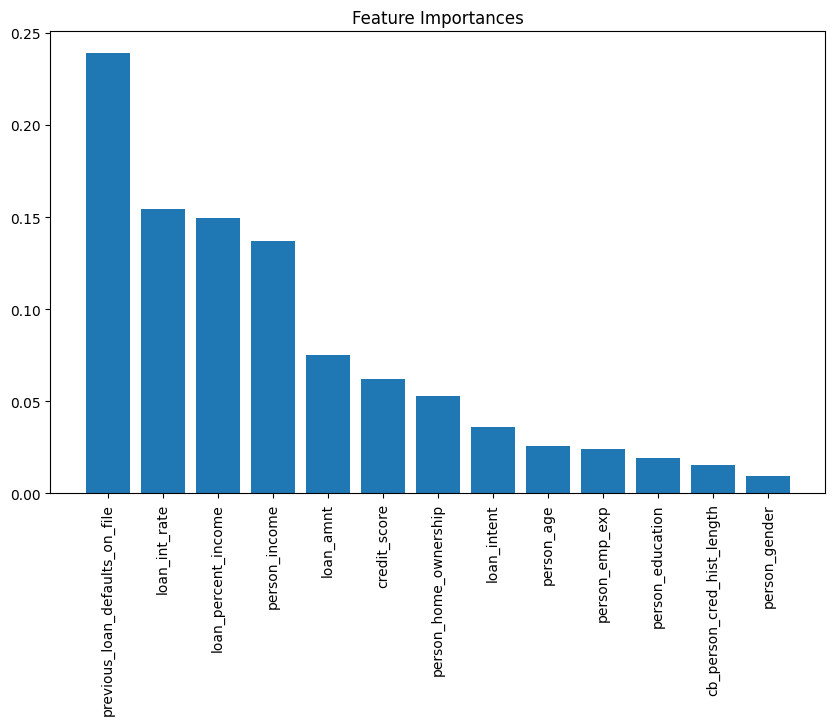

In [11]:
# --- STEP 6: Feature Importance (for tree models) ---
import matplotlib.pyplot as plt
import numpy as np

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    # Get column names from the original DataFrame X
    columns = X.columns

    plt.figure(figsize=(10,6))
    plt.title("Feature Importances")
    plt.bar(range(X_train.shape[1]), importances[indices], align='center')
    plt.xticks(range(X_train.shape[1]), [columns[i] for i in indices], rotation=90)
    plt.show()

In [12]:
# --- STEP 7: User Interactive Prediction (Single or Multiple Applicants) ---

# Use this template for new applicants with correct encoding
new_applicants = pd.DataFrame([
    {
        'person_age': 35,
        'person_gender': 1,  # Example encoded value
        'person_education': 2,
        'person_income': 60000,
        'person_emp_exp': 10,
        'person_home_ownership': 1,
        'loan_amnt': 300000,
        'loan_intent': 3,
        'loan_int_rate': 12.5,
        'loan_percent_income': 0.5,
        'cb_person_cred_hist_length': 8,
        'credit_score': 720,
        'previous_loan_defaults_on_file': 0
    },
    # Add more applicants as needed below
])

predictions = best_model.predict(new_applicants)
for idx, pred in enumerate(predictions):
    status = "Approved" if pred==1 else "Rejected"
    print(f"Applicant {idx+1}: {status}")

Applicant 1: Rejected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


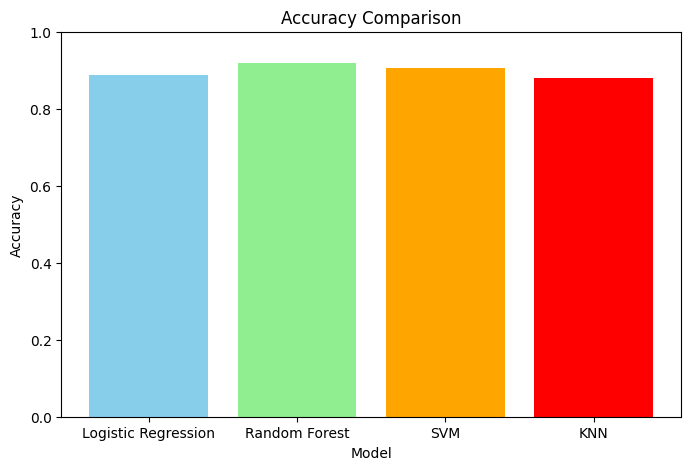

In [13]:
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color=['skyblue', 'lightgreen', 'orange', 'red'])
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.title('Accuracy Comparison')
plt.ylim([0, 1])
plt.show()


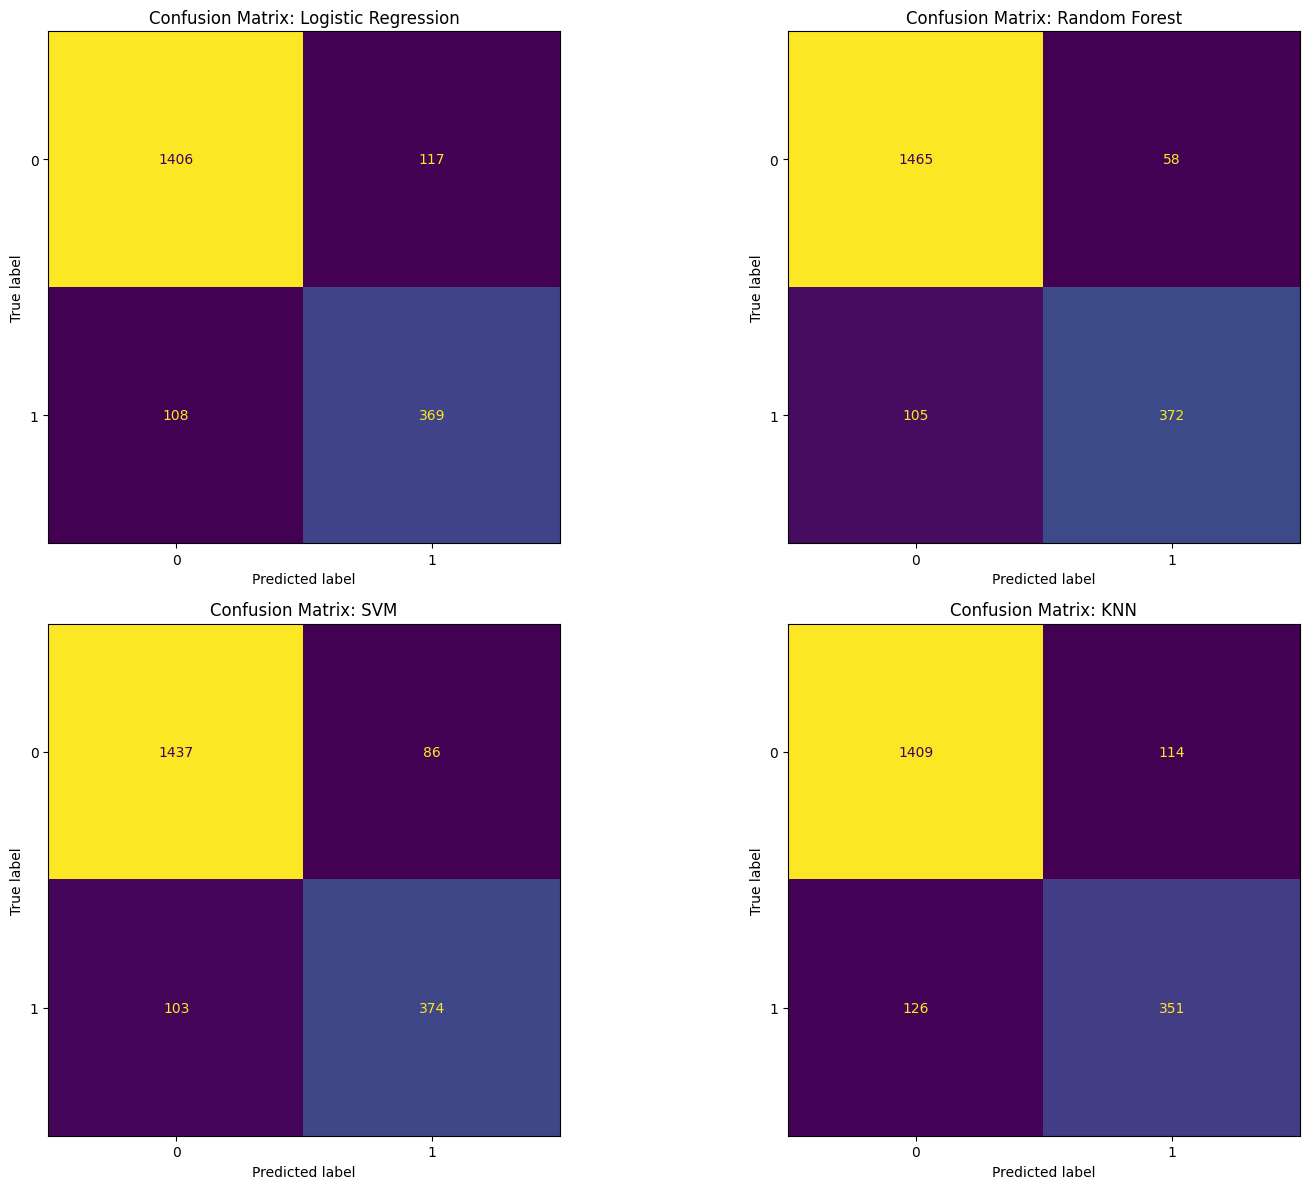

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Define model names for display order
model_names = ['Logistic Regression', 'Random Forest', 'SVM', 'KNN']

plt.figure(figsize=(16, 12))

for idx, name in enumerate(model_names):
    model = models[name]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(2, 2, idx + 1)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=plt.gca(), colorbar=False)
    plt.title(f"Confusion Matrix: {name}")

plt.tight_layout()
plt.show()
